#SETUP

In [9]:
import os
from dotenv import load_dotenv, find_dotenv
PERPLEXITY_KEY = os.getenv("PERPLEXITY_API_KEY")
os.environ["LANGSMITH_API_KEY"] = ""
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langsmith-academy"
env_path = find_dotenv()
load_dotenv(env_path, override=True)


True

Compiled graph type: <class 'langgraph.graph.state.CompiledStateGraph'>
Got graph object via compiled_graph.get_graph(): <class 'langchain_core.runnables.graph.Graph'>


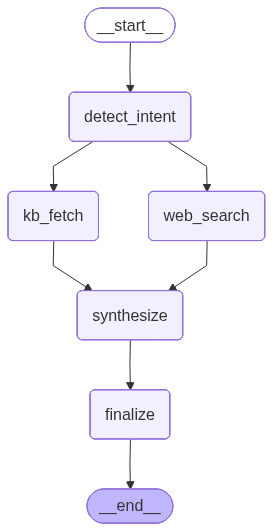

Rendered with draw_mermaid_png()


In [15]:
import sys, importlib, subprocess, os
from IPython.display import display, Image, SVG
from pathlib import Path
def ensure(pkg):
    try:
        importlib.import_module(pkg)
    except Exception:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
ensure("graphviz")
ensure("langgraph")
if "compiled_graph" not in globals():
    raise RuntimeError("compiled_graph not found in this notebook. Run the cell that builds/compiles the graph first.")

cg = compiled_graph
print("Compiled graph type:", type(cg))
gobj = None
if hasattr(cg, "get_graph"):
    try:
        gobj = cg.get_graph()
        print("Got graph object via compiled_graph.get_graph():", type(gobj))
    except Exception as e:
        print("compiled_graph.get_graph() raised:", repr(e))
else:
    print("compiled_graph has no get_graph() method. Available attrs:", sorted([a for a in dir(cg) if not a.startswith("_")])[:80])
render_attempts = []
rendered = False

if gobj is not None:
    # Try mermaid PNG (common in examples)
    if hasattr(gobj, "draw_mermaid_png"):
        try:
            png_bytes = gobj.draw_mermaid_png()
            if png_bytes:
                display(Image(png_bytes))
                print("Rendered with draw_mermaid_png()")
                rendered = True
        except Exception as e:
            render_attempts.append(("draw_mermaid_png", repr(e)))
    if not rendered and hasattr(gobj, "draw_png"):
        try:
            png_bytes = gobj.draw_png()
            if png_bytes:
                display(Image(png_bytes))
                print("Rendered with draw_png()")
                rendered = True
        except Exception as e:
            render_attempts.append(("draw_png", repr(e)))
    if not rendered and hasattr(gobj, "draw_svg"):
        try:
            svg_bytes = gobj.draw_svg()
            if svg_bytes:
                display(SVG(svg_bytes))
                print("Rendered with draw_svg()")
                rendered = True
        except Exception as e:
            render_attempts.append(("draw_svg", repr(e)))
if not rendered:
    print("\nCould not render the graph image. Attempts:", render_attempts)
    # Try to print mermaid source (if available)
    mermaid = None
    for candidate in ("to_mermaid", "draw_mermaid", "get_mermaid", "to_dot"):
        if hasattr(gobj, candidate):
            try:
                mermaid = getattr(gobj, candidate)()
                print(f"\nMermaid/Dot via {candidate}():\n")
                print(mermaid)
                break
            except Exception as e:
                print(f"{candidate}() raised {repr(e)}")
    if mermaid is None and hasattr(gobj, "to_mermaid"):
        try:
            mermaid = gobj.to_mermaid()
            print("\nMermaid:\n", mermaid)
        except Exception as e:
            print("to_mermaid() failed:", repr(e))